# A Machine Learning Algorithm for classifying whether any Turkish Headline 'Local' or 'Non-local'.

## Objection

I will build a machine learning algorithm for classifying Turkish News in terms of 'local news' or 'non-local news'. The main motivation behind this algorithm is the fuzzy nature of search pages of news outlets. Most of the web pages inject non-local headlines into local news. This algorithm will detect the real nature of the headline.

For this purpose, I scraped the local and non-local news based on special queries. Then I trained multiple algorithms to find the best fit.

This notebok has been written with Python language.

In [30]:
import sqlite3
import pandas as pd
# Create your connection.
cnx = sqlite3.connect('/home/suat/Dropbox/important_datum/il_haberleri/ilhaber.sqlite')

guya_yereller = pd.read_sql_query("SELECT * FROM haberler_gayri_mukerrer", cnx)

cnx2 = sqlite3.connect('/home/suat/Dropbox/important_datum/ulusal_haberler/ulusal_haberler.sqlite')

yerel_olmayanlar = pd.read_sql_query("SELECT * FROM haberler", cnx2)




The non-local headlines

In [31]:
yerel_olmayanlar.count()

baslik           13058
scrape_tarihi    13058
id               13058
sayfa_url        13058
sorgu_ifadesi    13058
dtype: int64

The local headlines

In [32]:
guya_yereller.count()

baslik           88378
sorgu_ifadesi    88378
sayfa_url        88378
insan_etiket      7699
dtype: int64

The clear terms about local news (like mayor, governor, village) will be extract from local headlines to label them as 'local'

In [33]:
yerel_haberler = pd.read_sql_query("""
SELECT * FROM haberler where baslik like '%vali%' 
                or baslik like '%kaymakam%'
                or baslik like '%mezra%'
                or baslik like '%müftü%'
                or baslik like '%muhtar%'
                or baslik like '%belediye başkanı%'
                or baslik like '%meclis üyesi%'
                or baslik like '%köy%'
                or baslik like '%mahalle%'
                or baslik like '%ilçe%'
                or baslik like '%il müdür%'
                or baslik like sorgu_ifadesi""", cnx)

In [34]:
yerel_haberler.count()

baslik           11864
scrape_tarihi    11864
id               11864
sayfa_url        11864
sorgu_ifadesi    11864
insan_etiket      1024
dtype: int64

Combining 'local' and 'non-local' news then labelling them

In [35]:
yerel_degil = yerel_olmayanlar.sample(5000)
yereldir = yerel_haberler.sample(5000)
yerel_degil['yerelmi']='yerel_degil'
yereldir['yerelmi']='yerel'

In [36]:
df = pd.concat([yerel_degil,yereldir])
df.sample(5)

/usr/lib/python3/dist-packages/ipykernel_launcher.py:1: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  """Entry point for launching an IPython kernel.


,baslik,id,insan_etiket,sayfa_url,scrape_tarihi,sorgu_ifadesi,yerelmi
12320,Korkunç cinayette sır perdesi aralandı,28c8d8d5414877d49aa8706021d901d2,NaN,haber7.com,24-01-2020,kanun,yerel_degil
859,25.09.2019 13:18 Yol çalışmasında bulunan ma...,9880edc70bb18742d7fe50c776268abe,None,sondakika.com,29-09-2019,Ankara,yerel
4332,CHP 71 belediye başkanını açıkladı... İşte tam...,52f760319239fabd7476b461589a20b4,None,cumhuriyet.com.tr,29-09-2019,Gümüşhane,yerel
4309,Suriye,7e63e744cf72af3f8296c5df7befd6ce,NaN,tr.mehrnews.com,24-01-2020,beşiktaş,yerel_degil
2284,Türkiye’nin ilk 'Yüzen Ofis'i ilgi çekiyor,1caaad793172bd4868641892b1856969,NaN,virahaber.com,24-01-2020,fenerbahçe,yerel_degil


In [81]:
from io import StringIO
col = ['yerelmi', 'baslik']
df = df[col]
df = df[pd.notnull(df['baslik'])]
df.columns = ['yerelmi', 'baslik']
df['category_id'] = df['yerelmi'].factorize()[0]
category_id_df = df[['yerelmi', 'category_id']].drop_duplicates().sort_values('category_id')
category_to_id = dict(category_id_df.values)
id_to_category = dict(category_id_df[['category_id', 'yerelmi']].values)

If category id is 0 news is non-local, else headline is local news

In [82]:
df.sample(10) # yerelse 1 

,yerelmi,baslik,category_id
12813,yerel_degil,Türkiye,0
10280,yerel,19.09.2019 16:49 19 Eylül Gaziler Günü Zongu...,1
2189,yerel,"16.09.2019 21:48 Vali Oktay Çağatay, Adilcev...",1
7244,yerel_degil,YATSI,0
8947,yerel,Muhtara tokat atıp kaçtılar,1
6377,yerel,23.09.2019 15:08 Milli sporcuların Avrupa ba...,1
10673,yerel,Üç ile vali ataması yapıldı,1
11169,yerel,09.09.2019 17:19 Kadirli'de 3 araç çarpıştı:...,1
7850,yerel_degil,14.01.2020 15:54 HDP TBMM Grup Toplantısı HD...,0
327,yerel,16.09.2019 16:27 Döğer'de 2. Yunus Emre'yi a...,1


Distribution of the news are normal

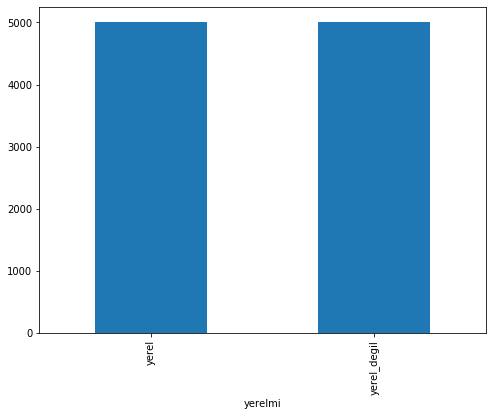

In [39]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,6))
df.groupby('yerelmi').baslik.count().plot.bar(ylim=0)
plt.show()

Stopwords removal:

In [93]:
from stop_words import get_stop_words
stop_words_tr = get_stop_words('tr')

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(sublinear_tf=True, 
                        min_df=5, norm='l2', encoding='utf-8', ngram_range=(1, 3), 
                        stop_words=stop_words_tr)
features = tfidf.fit_transform(df.baslik).toarray()
labels = df.category_id
features.shape

/usr/local/lib/python3.7/dist-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['insermi'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


(10000, 16579)

## Chi-Square Test to Find-out Most Relevant Term with Local and Non-local Headlines

In [96]:
from sklearn.feature_selection import chi2
import numpy as np
N = 2
for Product, category_id in sorted(category_to_id.items()):
  features_chi2 = chi2(features, labels == category_id)
  indices = np.argsort(features_chi2[0])
  feature_names = np.array(tfidf.get_feature_names())[indices]
  unigrams = [v for v in feature_names if len(v.split(' ')) == 1]
  bigrams = [v for v in feature_names if len(v.split(' ')) == 2]
  print("# '{}':".format(Product))
  print("  . Most correlated unigrams:\n. {}".format('\n. '.join(unigrams[-N:])))
  print("  . Most correlated bigrams:\n. {}".format('\n. '.join(bigrams[-N:])))

# 'yerel':
  . Most correlated unigrams:
. 2019
. 09
  . Most correlated bigrams:
. belediye başkanı
. 09 2019
# 'yerel_degil':
  . Most correlated unigrams:
. 2019
. 09
  . Most correlated bigrams:
. belediye başkanı
. 09 2019


## A experiment with Multionomial Naive Bayes Classifier

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
X_train, X_test, y_train, y_test = train_test_split(df['baslik'], df['category_id'], random_state = 0)

count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
clf = MultinomialNB().fit(X_train_tfidf, y_train)

# Experiment with Different Classifier to Select Best Performant Algorithm

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
import seaborn as sns

I will use 5 random cross-validation experiment for each algorithm

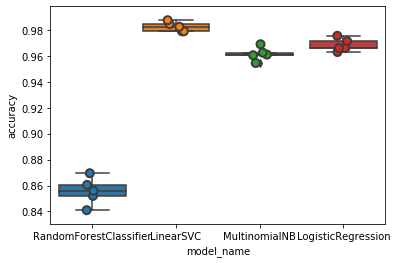

In [99]:
models = [
    RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0),
    LinearSVC(),
    MultinomialNB(),
    LogisticRegression(random_state=0),
]
CV = 5
cv_df = pd.DataFrame(index=range(CV * len(models)))
entries = []
for model in models:
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, features, labels, scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])

sns.boxplot(x='model_name', y='accuracy', data=cv_df)
sns.stripplot(x='model_name', y='accuracy', data=cv_df, 
              size=8, jitter=True, edgecolor="gray", linewidth=2)
plt.show()

Best peformance is with LinearSVC algorithm

In [100]:
cv_df.groupby('model_name').accuracy.mean()

model_name
LinearSVC                 0.9825
LogisticRegression        0.9684
MultinomialNB             0.9615
RandomForestClassifier    0.8558
Name: accuracy, dtype: float64


## Confusion Matrix

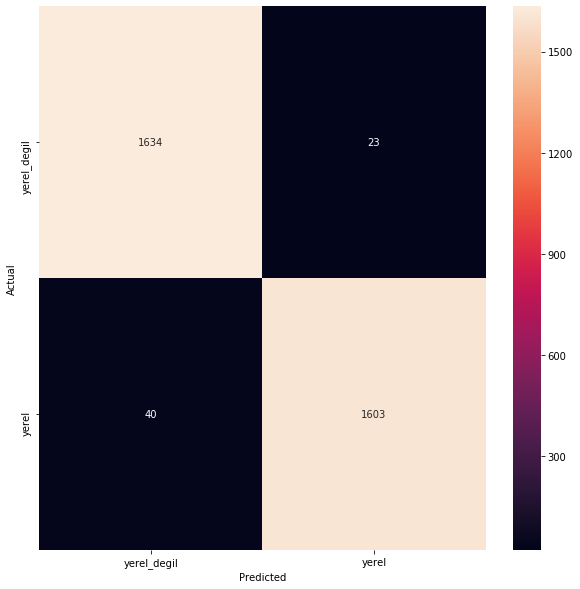

In [63]:
from sklearn.metrics import confusion_matrix

model = LinearSVC()
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(features, labels, df.index, test_size=0.33, random_state=0)
clf_linear_svc= model.fit(X_train, y_train)
y_pred = clf_linear_svc.predict(X_test)

conf_mat = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=category_id_df.yerelmi.values, yticklabels=category_id_df.yerelmi.values)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Train Selected Algorithm

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
X_train, X_test, y_train, y_test = train_test_split(df['baslik'], df['category_id'], random_state = 0)
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
clf_linear_svc = LinearSVC().fit(X_train_tfidf, y_train)
clf_linear_svc

LinearSVC(C=1.0, class_weight=None, dual=True, fit_intercept=True,
          intercept_scaling=1, loss='squared_hinge', max_iter=1000,
          multi_class='ovr', penalty='l2', random_state=None, tol=0.0001,
          verbose=0)

## Simple Test

In [102]:
x = """
Cumhurbaşkanlığı Kararnamesinde yer alan hususlar
"""
y = clf_linear_svc.predict(count_vect.transform([x]))[0]
print(category_id_df[category_id_df['category_id'] == y]['yerelmi'])

5032    yerel_degil
Name: yerelmi, dtype: object


In [71]:
x = """
Van'ın Gürpınar ilçesinde Norduz Koyunları ile ilgili
"""
y = clf_linear_svc.predict(count_vect.transform([x]))[0]
print(category_id_df[category_id_df['category_id'] == y]['yerelmi'])

6286    yerel
Name: yerelmi, dtype: object


# Labelling unlaballed headlines

In [109]:
#etiketsizler
dfx = pd.read_sql_query("""
SELECT  * FROM haberler_islenmis
""", cnx)

In [110]:
dfx['makine_etiket_yerelmi'] = None

In [111]:
dfx.count()

level_0                  80679
index                    80679
baslik                   80679
sorgu_ifadesi            80679
sayfa_url                80679
insan_etiket                 0
makine_etiket            80679
makine_etiket_id         80679
makine_etiket_yerelmi        0
dtype: int64

In [112]:
dfx.head(3)

,level_0,index,baslik,sorgu_ifadesi,sayfa_url,insan_etiket,makine_etiket,makine_etiket_id,makine_etiket_yerelmi
0,0,0,Dha yurt bülteni - 17,Adana,haberler.com,None,ol,2,None
1,1,1,Adana'da terör saldırısı,Adana,haberler.com,None,ol,2,None
2,2,2,Adana'da polis servis aracına saldırıda patlam...,Adana,haberler.com,None,ol,2,None


In [113]:
cincos = dfx
cincos.baslik
result_ids= clf_linear_svc.predict(count_vect.transform(cincos.baslik))
dfx['makine_etiket_yerelmi']= result_ids

## Converting numeric labels into human-friendly labels

In [114]:
# try
def convcat(catid):
    return "yerel" if catid == 1 else "yerel_degil"


dfx['makine_etiket_yerelmi']= dfx['makine_etiket_yerelmi'].apply(convcat)

In [117]:
dfx.sample(3)

,level_0,index,baslik,sorgu_ifadesi,sayfa_url,insan_etiket,makine_etiket,makine_etiket_id,makine_etiket_yerelmi
1271,1271,1271,Boynuz uzunluğu 127 santim olan yaban keçisi a...,Adıyaman,iha.com.tr,None,ol,2,yerel
56976,56976,56976,Türkiye 3 Bant Bilardo Şampiyonası başladı,Sinop,iha.com.tr,None,ol,2,yerel_degil
31672,31672,31672,Yönetmen Metin Günay'ın babası son yolculuğuna...,Isparta,iha.com.tr,None,ym,0,yerel_degil


In [121]:
#dfx.to_sql('haberler_islenmis',con=cnx,if_exists="replace")

## Results

Results shows that some webpage's search interface are pretty 'dirty'. It is show a lot of unrelevant things

In [164]:
gruplu_dfx = dfx.groupby(['sayfa_url','makine_etiket_yerelmi']).sum()
gruplu_dfx

level_0      index  \
sayfa_url          makine_etiket_yerelmi                         
bbc.com            yerel                   14628677   14628677   
                   yerel_degil             17068524   17068524   
cumhuriyet.com.tr  yerel                  109065882  109065882   
                   yerel_degil            211051271  211051271   
ensonhaber.com     yerel                     473463     473463   
                   yerel_degil              2209630    2209630   
ermenihaber.am     yerel                   22176919   22176919   
                   yerel_degil             60199430   60199430   
haber7.com         yerel                   17833059   17833059   
                   yerel_degil             53827623   53827623   
haberler.com       yerel                  358368614  358368614   
                   yerel_degil            225344696  225344696   
iha.com.tr         yerel                  477292865  477292865   
                   yerel_degil            399238760  399238760   
milligazete.com.tr yerel                  176312717  176312717   
                   yerel_degil            350337485  350337485   
posta.com.tr       yerel                   31166751   31166751   
                   yerel_degil             26135198   26135198   
sondakika.com      yerel                  366563966  366563966   
                   yerel_degil             11351338   11351338   
tr.euronews.com    yerel                   12562580   12562580   
                   yerel_degil             38535898   38535898   
tr.mehrnews.com    yerel                   11758767   11758767   
                   yerel_degil             77124361   77124361   
virahaber.com      yerel                   41997223   41997223   
                   yerel_degil            109330008  109330008   
yenisafak.com      yerel                   11329335   11329335   
                   yerel_degil             21225141   21225141   

                                          makine_etiket_id  
sayfa_url          makine_etiket_yerelmi                    
bbc.com            yerel                               554  
                   yerel_degil                         466  
cumhuriyet.com.tr  yerel                              3822  
                   yerel_degil                        5242  
ensonhaber.com     yerel                                 6  
                   yerel_degil                          36  
ermenihaber.am     yerel                               746  
                   yerel_degil                        1636  
haber7.com         yerel                               605  
                   yerel_degil                        1043  
haberler.com       yerel                             14485  
                   yerel_degil                        7300  
iha.com.tr         yerel                             19382  
                   yerel_degil                       12978  
milligazete.com.tr yerel                              5450  
                   yerel_degil                        8181  
posta.com.tr       yerel                              1231  
                   yerel_degil                         836  
sondakika.com      yerel                             17180  
                   yerel_degil                         454  
tr.euronews.com    yerel                               458  
                   yerel_degil                         873  
tr.mehrnews.com    yerel                               504  
                   yerel_degil                        1876  
virahaber.com      yerel                              1544  
                   yerel_degil                        3456  
yenisafak.com      yerel                               290  
                   yerel_degil                         554

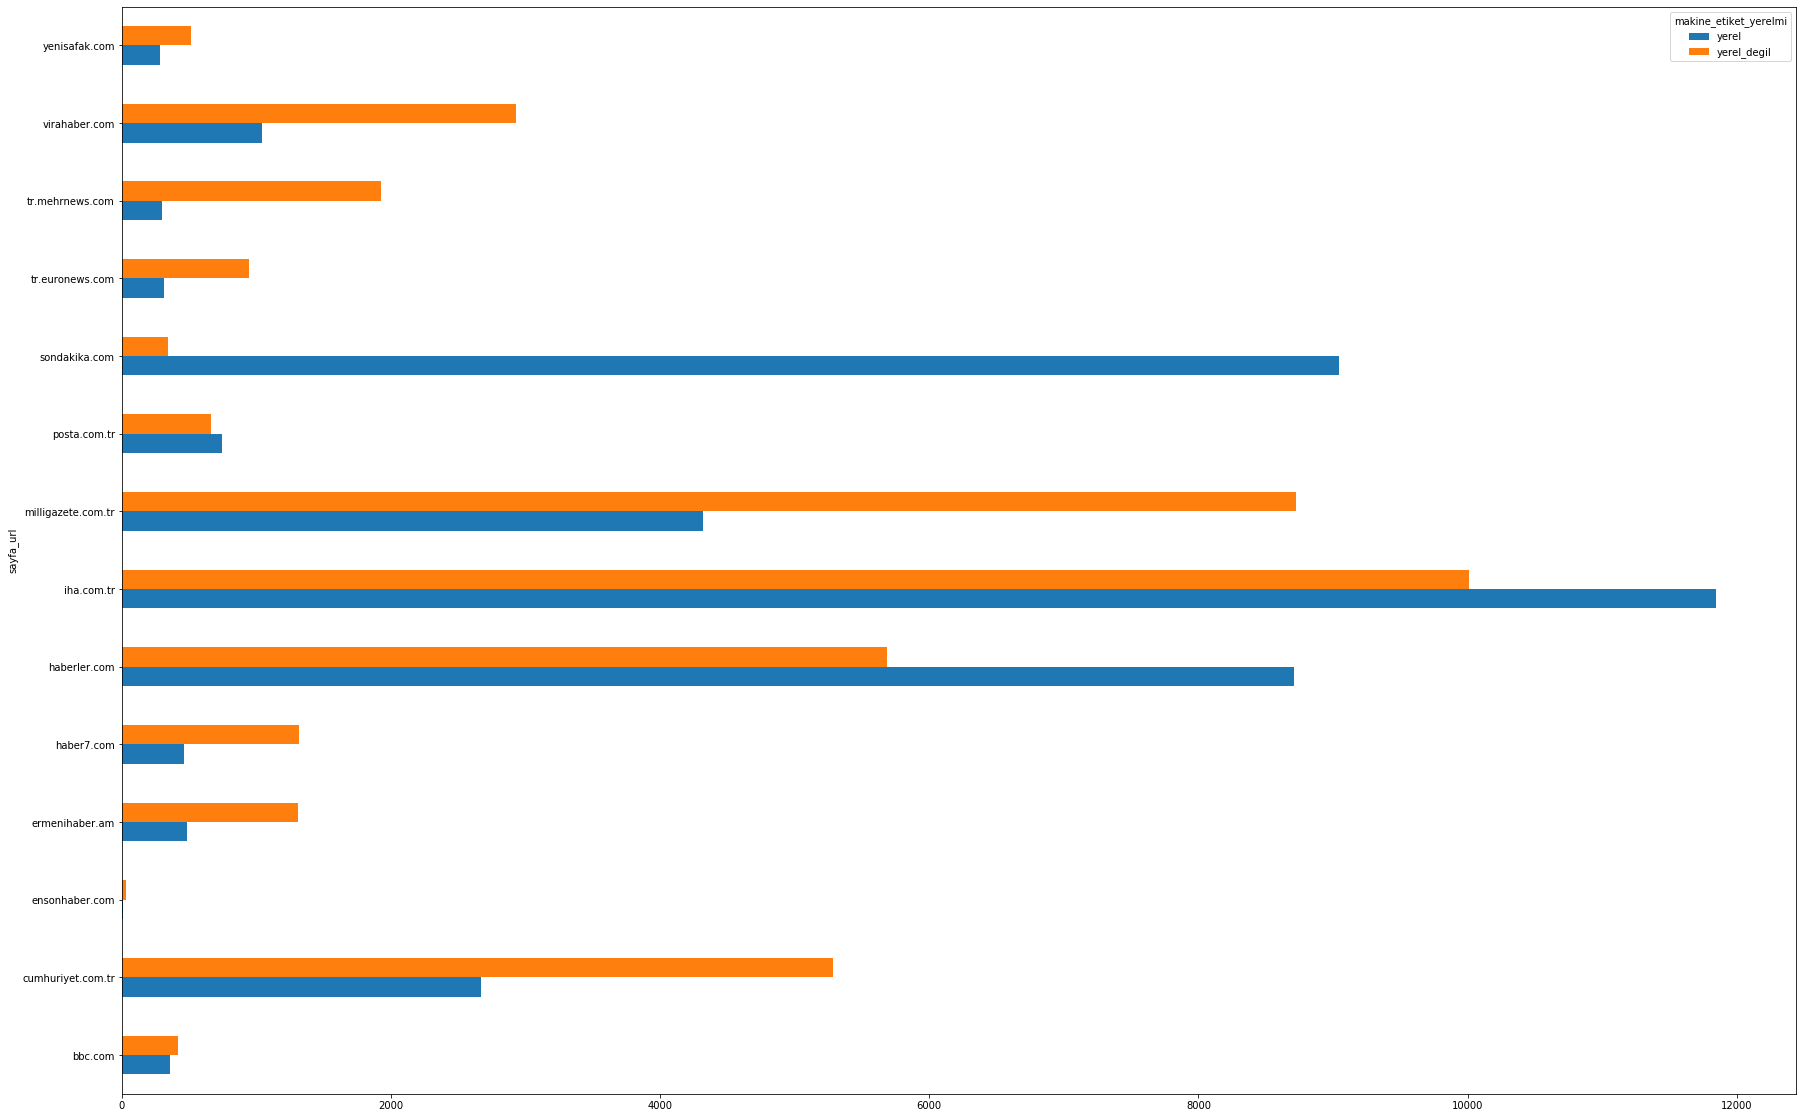

In [162]:
dfx.groupby(['sayfa_url','makine_etiket_yerelmi']).size().unstack().plot.barh(figsize=(30,20))